##**Experiment Number:- 05**

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

#### Load datset

In [163]:
df = pd.read_csv('spam.csv', encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [164]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [165]:
df = df.iloc[:,:2]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#### Encode labels (ham: 0, spam : 1)

In [166]:
df['label'] = df['label'].map({'ham':0, 'spam':1})
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


#### label

In [167]:
df['label'].value_counts()

,count
label,
0,4825
1,747


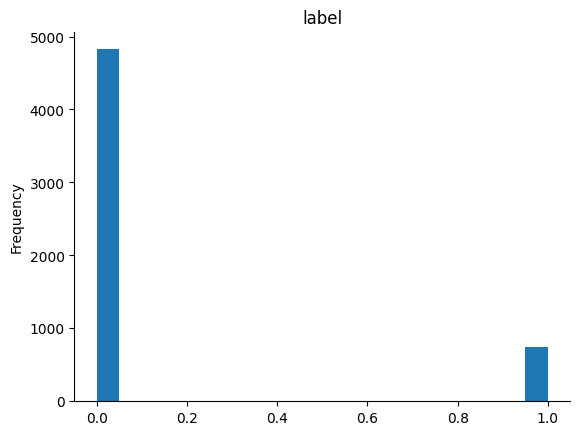

In [168]:
df['label'].plot(kind='hist', bins=20, title='label')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

#### Split the dataset into Train/Test

In [169]:
X_train,X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size= 0.2, random_state= 42)


#### Text vectorization

In [170]:
vectorize = TfidfVectorizer(stop_words='english',max_features= 5000, lowercase=True)
X_train_vec = vectorize.fit_transform(X_train)
X_test_vec = vectorize.transform(X_test)

In [171]:
print(X_train_vec)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 32322 stored elements and shape (4457, 5000)>
  Coords	Values
  (0, 588)	0.4658046386365619
  (0, 3257)	0.4528381701109944
  (0, 757)	0.3431839629173582
  (0, 4971)	0.348722265231364
  (0, 2051)	0.348722265231364
  (0, 3361)	0.4658046386365619
  (1, 499)	0.26161139982801973
  (1, 1981)	0.3059746053542906
  (1, 2472)	0.2804339696184593
  (1, 4426)	0.269833648032668
  (1, 664)	0.2015782058421696
  (1, 1502)	0.3059746053542906
  (1, 3837)	0.1937920260229529
  (1, 3133)	0.2953742837684993
  (1, 175)	0.28715203556385105
  (1, 3374)	0.3059746053542906
  (1, 4490)	0.2953742837684993
  (1, 728)	0.3059746053542906
  (1, 0)	0.2654936554684193
  (2, 1902)	0.5184025002061571
  (2, 4183)	0.46068881322362265
  (2, 740)	0.4087756496749903
  (2, 1031)	0.5932344674607208
  (3, 3862)	0.8109843385811522
  (3, 2950)	0.4132067802984986
  :	:
  (4451, 1319)	0.42592027058019766
  (4451, 3780)	0.42592027058019766
  (4452, 1926)	0.25923599228241945


#### Train the Logistic Regression

In [172]:
model = LogisticRegression()
model.fit(X_train_vec,y_train)

LogisticRegression()

#### Predictions

In [173]:
y_pred = model.predict(X_test_vec)

#### Accuracy

In [174]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9587443946188341


#### Classification report

In [175]:
print(f"Classification Report: {classification_report(y_test, y_pred)}")

Classification Report:               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.97      0.71      0.82       150

    accuracy                           0.96      1115
   macro avg       0.96      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



#### Confusion matrix

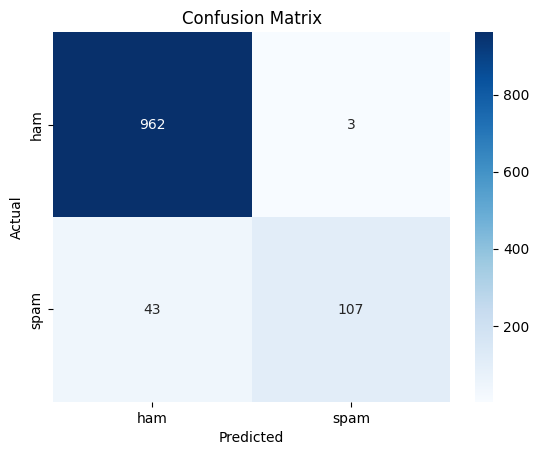

In [176]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot= True, fmt='d', cmap = 'Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()